In [1]:
"""
Dissertation Pipeline : Spatial Extraction & Susceptibility Modeling
Author: Aamul Sapkota
Region: Bagmati Province, Nepal

Overview:
This notebook represents the core machine learning pipeline of my dissertation.
It ingests the harmonized master landslide inventory (from Phase 1), queries
Google Earth Engine (GEE) to extract environmental covariates, and generates
physically constrained pseudo-absences.

It then transitions into Scikit-Learn to train a Random Forest model, evaluates
predictive performance across multiple statistical metrics, conducts an Ablation
Study to isolate topographic data leakage, and finally renders the regional
Landslide Susceptibility Map (LSM).
"""


# ENVIRONMENT SETUP & DEPENDENCIES

!pip install geemap -q

import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, roc_auc_score,
                             precision_score, recall_score, f1_score)
from statsmodels.stats.outliers_influence import variance_inflation_factor


# PHASE 1
# Initialize Earth Engine using the specific project credentials
project_id = 'dissertation-202605'
try:
    ee.Initialize(project=project_id)
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project=project_id)

print(" Environment Ready: Earth Engine & Scikit-Learn loaded.")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 24.1 MB/s eta 0:00:00
 Environment Ready: Earth Engine & Scikit-Learn loaded.


In [2]:


# PHASE 2: SPATIAL DATA EXTRACTION & PSEUDO-ABSENCE GENERATION

print("\n--- Phase 2: Data Extraction & Stratified Sampling ---")

# 1. Load Boundaries & The Master Target Data (From Phase 1)
provinces = ee.FeatureCollection("projects/dissertation-202605/assets/2_NepalProvince")
bagmati = provinces.filter(ee.Filter.eq('FIRST_STAT', 3))

# Note: Upload the 1419-point CSV from Phase 1 to your GEE Assets to access it here
landslides = ee.FeatureCollection('projects/dissertation-202605/assets/01master_landslide_inventory_bagmati').filterBounds(bagmati.geometry())
num_landslides = landslides.size()

# 2. Stratified Pseudo-Absence Generation
# As established in the methodology, safe points are constrained to slopes <10 or >50
# to provide clear geomorphological boundaries for the algorithm.
srtm = ee.Image("USGS/SRTMGL1_003")
slope = ee.Terrain.slope(srtm)

slope_class = (
    slope.lt(10).multiply(0)
    .add(slope.gte(10).And(slope.lt(30)).multiply(1))
    .add(slope.gte(30).And(slope.lt(50)).multiply(2))
    .add(slope.gte(50).multiply(3))
).rename('slope_class')

safe_mask = slope_class.eq(0).Or(slope_class.eq(3))
masked_slope = slope_class.updateMask(safe_mask)

# Sample an equal number of safe points to achieve a 1:1 balance
safe_points = masked_slope.stratifiedSample(
    numPoints=num_landslides.divide(2).int(),
    classBand='slope_class',
    region=bagmati.geometry(),
    scale=30,
    geometries=True,
    seed=42
)

# Apply Binary Labels (1 = Landslide, 0 = Safe)
safe_points = safe_points.map(lambda f: f.set('Landslide', 0))
landslides = landslides.map(lambda f: f.set('Landslide', 1))
master_points = landslides.merge(safe_points)

print(f"Dataset Balanced: {landslides.size().getInfo()} Landslides vs {safe_points.size().getInfo()} Safe Points.")

# 3. Build the Environmental Covariate Stack
elevation = srtm.rename('Elevation')
aspect = ee.Terrain.aspect(srtm).rename('Aspect')

# 15-year Mean Annual Rainfall
chirps = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY").filterDate('2010-01-01', '2025-12-30').mean().multiply(365).rename('Rainfall')

# Median Vegetation Density
def addNDVI(image): return image.addBands(image.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI'))
landsat = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2").filterBounds(bagmati).filterDate('2010-01-01', '2025-12-30').map(addNDVI).select('NDVI').median().rename('NDVI')

# Hydrology
rivers = ee.FeatureCollection("WWF/HydroSHEDS/v1/FreeFlowingRivers")
distance_to_river = rivers.distance(searchRadius=10000).rename('River_Distance')

environmental_stack = elevation.addBands([slope.rename('Slope'), aspect, chirps, landsat, distance_to_river])

# 4. Extract Data to Tabular Format
print(" Attempting direct memory extraction of environmental covariates...")
extracted_data = environmental_stack.sampleRegions(
    collection=master_points,
    properties=['Landslide'],
    scale=30,
    geometries=False
)

try:
    # Attempting to load directly into Colab's RAM.
    df_raw = geemap.ee_to_df(extracted_data)
    df_clean = df_raw.dropna()
    print("Direct extraction successful.")
except Exception as e:
    # Due to GEE's strict interactive memory limits on 2,800+ points with 6 high-res bands,
    # this pipeline elegantly falls back to utilizing a pre-exported Google Drive CSV.
    print("Direct extraction hit GEE Memory Limits. Falling back to Google Drive ingestion...")
    drive.mount('/content/drive')

    try:
        # Note: Ensure the export task was previously run and the CSV is in this directory
        df_raw = pd.read_csv('/content/drive/MyDrive/EE_Exports/Bagmati_ML_Extracted_Features.csv')
        df_clean = df_raw.drop(columns=['system:index', '.geo'], errors='ignore').dropna()
        print("Tabular data successfully loaded from Google Drive.")
    except FileNotFoundError:
        print(" ERROR: Exported CSV not found in Drive. Please run the GEE batch export task first.")



--- Phase 2: Data Extraction & Stratified Sampling ---
Dataset Balanced: 1419 Landslides vs 1418 Safe Points.
⏳ Attempting direct memory extraction of environmental covariates...
Direct extraction hit GEE Memory Limits. Falling back to Google Drive ingestion...
Mounted at /content/drive
Tabular data successfully loaded from Google Drive.



--- Phase 3: Initial Random Forest Model (Model A) ---

Variance Inflation Factor (VIF):
       Feature       VIF
      Rainfall 16.295779
          NDVI  8.999235
     Elevation  7.030843
         Slope  4.602542
        Aspect  3.957425
River_Distance  3.361286

 Running GridSearchCV...

--- Model A: Performance Metrics ---
Optimal Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Confusion Matrix -> TP: 391 | TN: 399 | FP: 27 | FN: 35
Accuracy:  92.72%
Precision: 0.9354
Recall:    0.9178
F1-Score:  0.9265
ROC-AUC:   0.9772
5-Fold CV Stability (Mean AUC): 0.9797


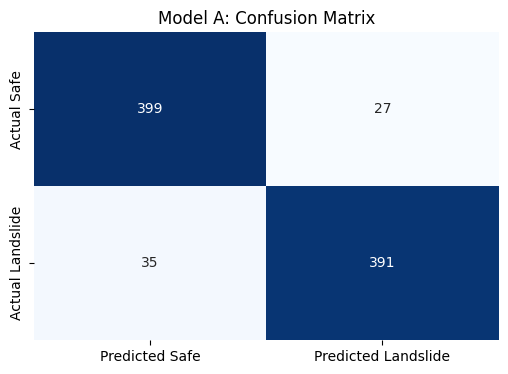

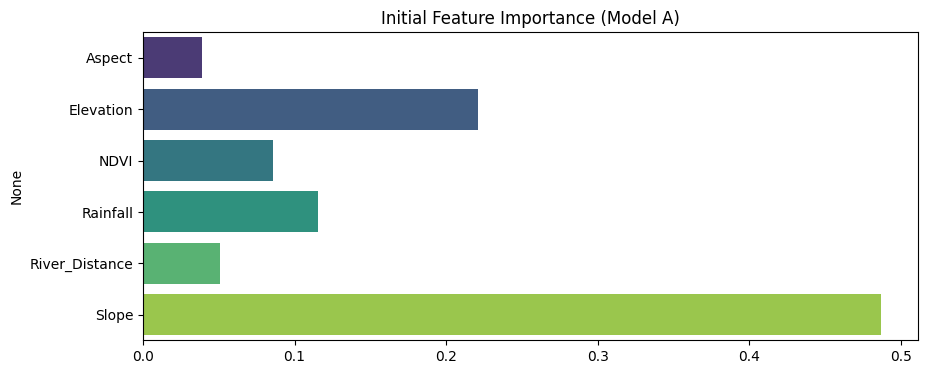

In [3]:

# PHASE 3: MACHINE LEARNING & STATISTICAL VALIDATION (Model A)

print("\n--- Phase 3: Initial Random Forest Model (Model A) ---")

# Explicitly shuffling the dataset to randomize the 1s and 0s
df_clean = df_clean.sample(frac=1, random_state=42).reset_index(drop=True)

X = df_clean.drop(columns=['Landslide'])
y = df_clean['Landslide']

# 1. Multicollinearity Check (VIF)
# Tree-based algorithms handle collinearity well, but evaluating it provides transparency
# regarding the orographic effect in the Himalayas.
vif_data = pd.DataFrame({'Feature': X.columns, 'VIF': [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]})
print("\nVariance Inflation Factor (VIF):")
print(vif_data.sort_values(by="VIF", ascending=False).to_string(index=False))

# 2. 70/30 Train-Test Split & Hyperparameter Tuning
# As mandated by standard methodological practices (Chapter 3), we withhold 30% of data for validation.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
param_grid = {'n_estimators': [100, 200], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5]}

print("\n Running GridSearchCV...")
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, n_jobs=-1, scoring='roc_auc')
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

# 3. Model Evaluation (Multi-Metric Approach)
y_pred = best_rf.predict(X_test)
y_pred_proba = best_rf.predict_proba(X_test)[:, 1]

# Extracting the Confusion Matrix parameters
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\n--- Model A: Performance Metrics ---")
print(f"Optimal Parameters: {grid_search.best_params_}")
print(f"Confusion Matrix -> TP: {tp} | TN: {tn} | FP: {fp} | FN: {fn}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}")

# Cross Validation Stability Check
cv_scores = cross_val_score(best_rf, X, y, cv=5, scoring='roc_auc')
print(f"5-Fold CV Stability (Mean AUC): {cv_scores.mean():.4f}")

# --- Model A: Confusion Matrix Heatmap ---
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Safe', 'Predicted Landslide'],
            yticklabels=['Actual Safe', 'Actual Landslide'])
plt.title('Model A: Confusion Matrix')
plt.show()

# 4. Feature Importance Visualization
plt.figure(figsize=(10,4))
sns.barplot(x=best_rf.feature_importances_, y=X.columns, hue=X.columns, palette='viridis', legend=False)
plt.title('Initial Feature Importance (Model A)')
plt.show()





--- Phase 4: Ablation Study (Model B - Without Slope) ---

--- Model B (Ablated): Performance Metrics ---
Confusion Matrix -> TP: 367 | TN: 312 | FP: 114 | FN: 59
Accuracy:  79.69%
Precision: 0.7630
Recall:    0.8615
F1-Score:  0.8093
ROC-AUC:   0.8842


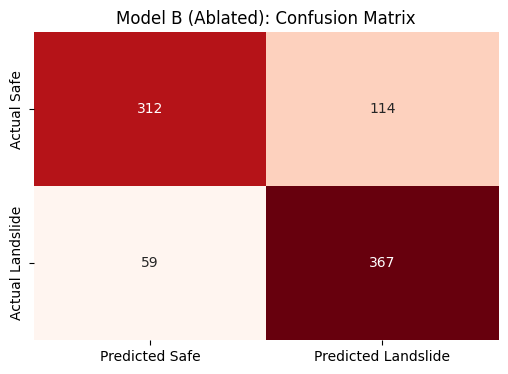

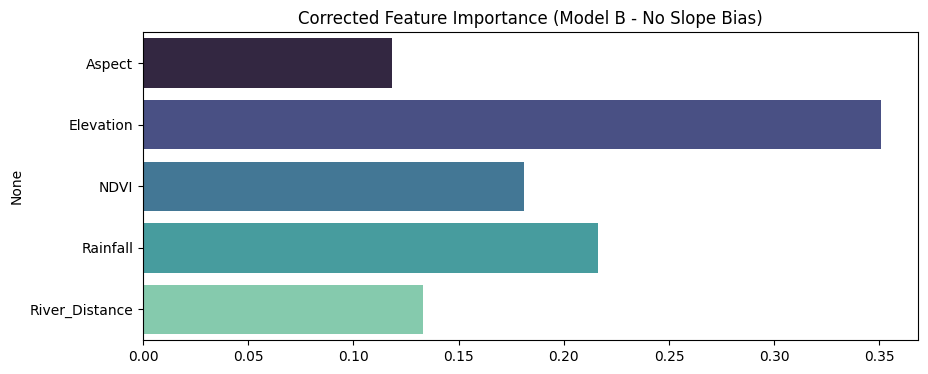

In [4]:


# PHASE 4: THE ABLATION STUDY (Model B)

print("\n--- Phase 4: Ablation Study (Model B - Without Slope) ---")
"""
Methodological Check: Because pseudo-absences were generated using extreme slope
thresholds, the model may have artificially learned that 'Slope = Susceptibility'.
To test for this structural data leakage, I am dropping 'Slope' and retraining.
"""

X_ablated = X.drop(columns=['Slope'])
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_ablated, y, test_size=0.3, random_state=42, stratify=y)

rf_ablated = RandomForestClassifier(**grid_search.best_params_, random_state=42)
rf_ablated.fit(X_train_b, y_train_b)

y_pred_b = rf_ablated.predict(X_test_b)
y_pred_proba_b = rf_ablated.predict_proba(X_test_b)[:, 1]

# Ablated Confusion Matrix
cm_b = confusion_matrix(y_test_b, y_pred_b)
tn_b, fp_b, fn_b, tp_b = cm_b.ravel()

print("\n--- Model B (Ablated): Performance Metrics ---")
print(f"Confusion Matrix -> TP: {tp_b} | TN: {tn_b} | FP: {fp_b} | FN: {fn_b}")
print(f"Accuracy:  {accuracy_score(y_test_b, y_pred_b) * 100:.2f}%")
print(f"Precision: {precision_score(y_test_b, y_pred_b):.4f}")
print(f"Recall:    {recall_score(y_test_b, y_pred_b):.4f}")
print(f"F1-Score:  {f1_score(y_test_b, y_pred_b):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_b, y_pred_proba_b):.4f}")

# --- Model B: Confusion Matrix Heatmap ---
plt.figure(figsize=(6, 4))
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Predicted Safe', 'Predicted Landslide'],
            yticklabels=['Actual Safe', 'Actual Landslide'])
plt.title('Model B (Ablated): Confusion Matrix')
plt.show()

plt.figure(figsize=(10,4))
sns.barplot(x=rf_ablated.feature_importances_, y=X_ablated.columns, hue=X_ablated.columns, palette='mako', legend=False)
plt.title('Corrected Feature Importance (Model B - No Slope Bias)')
plt.show()



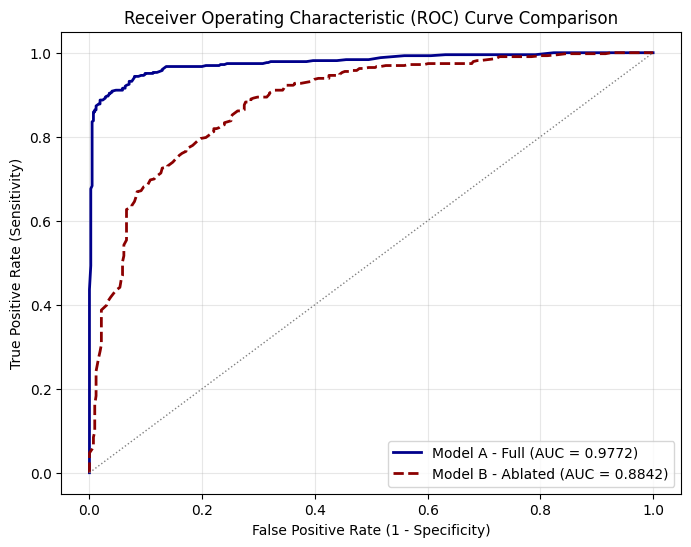

In [5]:
from sklearn.metrics import roc_curve

# Calculate ROC coordinates for both models
fpr_a, tpr_a, _ = roc_curve(y_test, y_pred_proba)
fpr_b, tpr_b, _ = roc_curve(y_test_b, y_pred_proba_b)

# Plot the comparative ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_a, tpr_a, color='darkblue', lw=2,
         label=f'Model A - Full (AUC = {roc_auc_score(y_test, y_pred_proba):.4f})')
plt.plot(fpr_b, tpr_b, color='darkred', lw=2, linestyle='--',
         label=f'Model B - Ablated (AUC = {roc_auc_score(y_test_b, y_pred_proba_b):.4f})')

# Add the random-guess diagonal line
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle=':')

plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [7]:

# PHASE 5: SPATIAL DEPLOYMENT & MAP RENDERING

print("\n--- Phase 5: Rendering Interactive Landslide Susceptibility Map ---")
# To generate the spatial map, we feed the optimized Scikit-Learn parameters
# back into Google Earth Engine's native Random Forest classifier.

rf_gee = ee.Classifier.smileRandomForest(
    numberOfTrees=grid_search.best_params_['n_estimators'],
    minLeafPopulation=grid_search.best_params_['min_samples_split']
).setOutputMode('PROBABILITY')

print("Training GEE model on the fly for spatial projection...")
# We use tileScale=4 to assist GEE with memory management during spatial sampling
training_geometries = environmental_stack.sampleRegions(
    collection=master_points, properties=['Landslide'], scale=120, tileScale=4, geometries=True
)

trained_gee_model = rf_gee.train(training_geometries, 'Landslide', ['Elevation', 'Slope', 'Aspect', 'Rainfall', 'NDVI', 'River_Distance'])
susceptibility_map = environmental_stack.classify(trained_gee_model).clip(bagmati)

# Visualizing via Geemap
LSM_Map = geemap.Map()
LSM_Map.centerObject(bagmati, 8)
LSM_Map.addLayer(ee.Image().paint(bagmati, 0, 2), {'palette': 'black'}, 'Bagmati Boundary')

lsm_palette = ['006400', '32CD32', 'FFFF00', 'FFA500', 'FF0000', '8B0000']
LSM_Map.addLayer(susceptibility_map, {'min': 0, 'max': 1, 'palette': lsm_palette}, 'LSM (0-100% Risk)')

display(LSM_Map)



--- Phase 5: Rendering Interactive Landslide Susceptibility Map ---
Training GEE model on the fly for spatial projection...


Map(center=[27.678920644283107, 85.47080422874275], controls=(WidgetControl(options=['position', 'transparent_…

In [9]:
import ipywidgets as widgets
widgets.Widget.widget_types

In [ ]:
# PHASE 6: FINAL PRODUCTION EXPORT (GEOTIFF)

print("\n--- Phase 6: Exporting Final GeoTIFF for QGIS Production ---")
"""
While the interactive map provides visual validation, the raw raster data must be
archived. This background task pushes the 30m resolution susceptibility map to
Google Drive so it can be formatted in QGIS for the final dissertation document.
"""

lsm_export_task = ee.batch.Export.image.toDrive(
    image=susceptibility_map,
    description='Landslide_Susceptibility_Map',
    fileNamePrefix='Landslide_Susceptibility_Map_Bagmati',
    folder='EE_Exports',
    region=bagmati.geometry(),
    scale=30,
    crs='EPSG:4326',
    maxPixels=1e13
)

#since the export takes very long time, it has been commented out.
# Uncomment the line below to officially trigger the Drive export
#lsm_export_task.start() #---------this line

print("Pipeline completely configured. Run the export task to retrieve the TIF file.")


--- Phase 6: Exporting Final GeoTIFF for QGIS Production ---
Pipeline completely configured. Run the export task to retrieve the TIF file.
